# PS2 — Dynamic Multi-Level Fee Choice under Incomplete Information

This notebook studies transaction-priority allocation when two users with different delay costs make fee choices across three connected rounds.

Each user has a fixed private type, **Urgent** or **Patient**, and chooses **Low**, **Medium**, or **High** in every round. A higher fee receives confirmation priority. If the fees are equal, confirmation is determined by a seeded 50/50 tie-break. The unconfirmed user accumulates waiting age, so an outcome in one round changes the state of the next round.

The analysis has three connected parts:

1. a strategic benchmark for the simultaneous fee-choice decision;
2. a computational comparison of complete information, incomplete information, and incomplete information with a nonbinding coordination signal;
3. allocation and welfare measures that separate priority quality from fee and delay costs.

The same types, actions, state transition, and information conditions are used in the Hugging Face behavioral interface.


## 1. Model

For user $i\in\{1,2\}$, the fixed private type is

$$
\theta_i\in\{U,P\},
$$

where $U$ is Urgent and $P$ is Patient.

In round $t\in\{1,2,3\}$, the action is

$$
a_{i,t}\in\{L,M,H\}.
$$

The fee costs are

$$
c(L)=1,\qquad c(M)=2,\qquad c(H)=3.
$$

Type-specific parameters are

$$
V_U=8,\quad d_U=2,
$$

$$
V_P=5,\quad d_P=1,
$$

where $V_\theta$ is confirmation value and $d_\theta$ is delay cost per waiting step.

The prior probability of an Urgent type is

$$
\Pr(\theta_i=U)=0.6.
$$


## 2. State transition and payoff

Let $w_{i,t}$ be user $i$'s waiting age before round $t$.

The higher fee receives confirmation priority. If both users choose the same fee, the tie is resolved by a seeded 50/50 draw.

After the round,

$$
w_{i,t+1}=
\begin{cases}
0, & \text{if user }i\text{ is confirmed},\\
w_{i,t}+1, & \text{otherwise}.
\end{cases}
$$

The per-round payoff is

$$
u_{i,t}=
\begin{cases}
V_{\theta_i}-c(a_{i,t}), & \text{if confirmed},\\
-d_{\theta_i}w_{i,t+1}, & \text{if not confirmed}.
\end{cases}
$$

This makes the game dynamic because the current allocation changes the next-round waiting state.


## 3. Strategic benchmark and justified prediction

The game is dynamic because waiting carries across rounds, but each round contains a simultaneous strategic fee-choice problem under private information. We use a **state-contingent stage Bayesian Nash benchmark** as the tractable game-theoretic prediction for this classroom model.

Consider a user of type $\theta$ with current waiting age $w$. If the opponent chooses High, choosing Low or Medium loses confirmation priority with certainty, giving

$$
u_\theta(a<H\mid H,w)=-d_\theta(w+1).
$$

Choosing High creates a same-fee tie. Because ties are resolved 50/50,

$$
EU_\theta(H\mid H,w)
=
\frac{1}{2}\left[V_\theta-c(H)\right]
+
\frac{1}{2}\left[-d_\theta(w+1)\right].
$$

Therefore High is a strict best response to High whenever

$$
V_\theta-c(H)+d_\theta(w+1)>0.
$$

Under the calibration

$$
(V_U,d_U)=(8,2),\qquad (V_P,d_P)=(5,1),\qquad c(H)=3,
$$

this inequality holds for both types and every waiting state reached in the three-round game. Thus

$$
(H,H)
$$

is a **stage Bayesian Nash equilibrium** at every state: neither type wants to unilaterally lower its fee when it expects the opponent to choose High.

This benchmark gives a clear strategic prediction. Individual incentives can push both users toward the highest fee even though the resulting same-fee outcome does not differentiate transaction priority. The computational comparison below asks whether information and a nonbinding coordination signal can improve allocation relative to decentralized state-responsive behavior.

### State-responsive comparison policy

For the multi-round simulations, we also use a transparent type-and-wait policy:

$$
\pi(U,w)=
\begin{cases}
M,&w=0,\\
H,&w\ge 1,
\end{cases}
\qquad
\pi(P,w)=
\begin{cases}
L,&w=0,\\
M,&w=1,\\
H,&w\ge 2.
\end{cases}
$$

This policy is a **comparison policy**, not the equilibrium result above. It represents a simple behavioral rule in which greater urgency or accumulated waiting leads to a weakly higher fee. Keeping the strategic benchmark and the simulation policy separate lets us compare a game-theoretic prediction with a transparent state-dependent behavioral baseline.


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ACTIONS = ["L", "M", "H"]
FEE = {"L": 1, "M": 2, "H": 3}

PARAMS = {
    "Urgent": {"value": 8, "delay": 2},
    "Patient": {"value": 5, "delay": 1},
}

P_URGENT = 0.60
ROUNDS = 3
TREMBLE = 0.03
SIGNAL_FOLLOW = 0.85
BASE_SEED = 206

def base_policy(user_type, wait):
    if user_type == "Urgent":
        return "H" if wait >= 1 else "M"
    if wait >= 2:
        return "H"
    if wait >= 1:
        return "M"
    return "L"

def recommendations(type1, wait1, type2, wait2, rng):
    score1 = (2 if type1 == "Urgent" else 0) + wait1
    score2 = (2 if type2 == "Urgent" else 0) + wait2

    if score1 == score2:
        user1_priority = rng.random() < 0.5
    else:
        user1_priority = score1 > score2

    priority_type = type1 if user1_priority else type2
    priority_wait = wait1 if user1_priority else wait2
    upper = "H" if (priority_type == "Urgent" or priority_wait > 0) else "M"

    return (upper, "L") if user1_priority else ("L", upper)

def apply_tremble(action, rng, probability=TREMBLE):
    if rng.random() >= probability:
        return action
    alternatives = [a for a in ACTIONS if a != action]
    return alternatives[int(rng.random() * len(alternatives))]


In [2]:
# Verify the stage-game best-response condition used in the strategic benchmark.

rows = []

for user_type in ["Urgent", "Patient"]:
    V = PARAMS[user_type]["value"]
    d = PARAMS[user_type]["delay"]

    for wait in range(3):
        # If the opponent chooses H, choosing L or M loses priority for sure.
        lower_fee_payoff = -d * (wait + 1)

        # Choosing H against H creates a 50/50 tie.
        high_vs_high = (
            0.5 * (V - FEE["H"])
            + 0.5 * lower_fee_payoff
        )

        rows.append({
            "type": user_type,
            "wait": wait,
            "payoff_lower_fee_vs_H": lower_fee_payoff,
            "expected_payoff_H_vs_H": high_vs_high,
            "H_is_strict_best_response_to_H": high_vs_high > lower_fee_payoff,
        })

strategic_benchmark = pd.DataFrame(rows)
strategic_benchmark


,type,wait,payoff_lower_fee_vs_H,expected_payoff_H_vs_H,H_is_strict_best_response_to_H
0,Urgent,0,-2,1.5,True
1,Urgent,1,-4,0.5,True
2,Urgent,2,-6,-0.5,True
3,Patient,0,-1,0.5,True
4,Patient,1,-2,0.0,True
5,Patient,2,-3,-0.5,True


## 4. Three information conditions

We compare three information and coordination environments in the same three-round state-dependent game.

### Complete-information benchmark

Both users' types and waiting states are available to the coordination rule, which assigns differentiated nonbinding fee recommendations.

### Incomplete information

Each synthetic user follows the state-responsive comparison policy using only its own type and waiting age.

### Incomplete information + signal

Private types remain hidden from the other user. The system sends differentiated, nonbinding recommendations. Each synthetic user follows the recommendation with probability

$$
\rho=0.85
$$

and otherwise follows the state-responsive comparison policy.

A small $3\%$ tremble is applied in all conditions to match the Hugging Face synthetic-opponent implementation.


In [3]:
def choose_action(condition, user_type, wait, recommendation, rng,
                  signal_follow=SIGNAL_FOLLOW):
    if condition == "complete":
        action = recommendation
    elif condition == "signal":
        if rng.random() < signal_follow:
            action = recommendation
        else:
            action = base_policy(user_type, wait)
    elif condition == "incomplete":
        action = base_policy(user_type, wait)
    else:
        raise ValueError("Unknown condition")
    return apply_tremble(action, rng)

def simulate_session(condition, rng, signal_follow=SIGNAL_FOLLOW):
    type1 = "Urgent" if rng.random() < P_URGENT else "Patient"
    type2 = "Urgent" if rng.random() < P_URGENT else "Patient"
    wait1 = wait2 = 0
    records = []

    for round_id in range(1, ROUNDS + 1):
        rec1, rec2 = recommendations(type1, wait1, type2, wait2, rng)

        action1 = choose_action(
            condition, type1, wait1, rec1, rng, signal_follow
        )
        action2 = choose_action(
            condition, type2, wait2, rec2, rng, signal_follow
        )

        same_fee = action1 == action2

        if FEE[action1] > FEE[action2]:
            user1_confirmed = True
        elif FEE[action1] < FEE[action2]:
            user1_confirmed = False
        else:
            user1_confirmed = rng.random() < 0.5

        next_wait1 = 0 if user1_confirmed else wait1 + 1
        next_wait2 = wait2 + 1 if user1_confirmed else 0

        payoff1 = (
            PARAMS[type1]["value"] - FEE[action1]
            if user1_confirmed
            else -PARAMS[type1]["delay"] * next_wait1
        )
        payoff2 = (
            PARAMS[type2]["value"] - FEE[action2]
            if not user1_confirmed
            else -PARAMS[type2]["delay"] * next_wait2
        )

        # Only the confirmed user pays the selected fee.
        # Since exactly one transaction is confirmed each round, this is also
        # the fee paid per confirmed transaction.
        fee_expenditure = FEE[action1] if user1_confirmed else FEE[action2]

        score1 = (2 if type1 == "Urgent" else 0) + wait1
        score2 = (2 if type2 == "Urgent" else 0) + wait2

        if score1 == score2:
            priority_aligned = np.nan
        else:
            priority_aligned = (
                user1_confirmed if score1 > score2 else not user1_confirmed
            )

        if type1 == type2:
            urgent_confirmed = np.nan
        else:
            urgent_confirmed = (
                user1_confirmed if type1 == "Urgent" else not user1_confirmed
            )

        records.append({
            "round": round_id,
            "type1": type1,
            "type2": type2,
            "wait1_before": wait1,
            "wait2_before": wait2,
            "action1": action1,
            "action2": action2,
            "same_fee": same_fee,
            "user1_confirmed": user1_confirmed,
            "payoff1": payoff1,
            "payoff2": payoff2,
            "total_welfare": payoff1 + payoff2,
                "fee_expenditure": fee_expenditure,
            "mean_wait_after": (next_wait1 + next_wait2) / 2,
            "priority_aligned": priority_aligned,
            "urgent_confirmed": urgent_confirmed,
        })

        wait1, wait2 = next_wait1, next_wait2

    return records


## 5. Monte Carlo comparison

We simulate many independent three-round sessions under each information condition.

Main metrics:

- **same-fee collision rate**: fraction of rounds with identical fee choices;
- **priority alignment**: when the two pre-round priority scores differ, whether the higher-score user is confirmed;
- **urgent confirmation rate**: when types differ, whether the Urgent user is confirmed;
- **mean waiting age** after a round;
- **mean total welfare** per round.

The same-fee metric is now called a **fee collision** rather than automatically calling every tie congestion, because a tied fee is still resolved by a 50/50 confirmation draw in .


### Payment measure

**Fee expenditure** is the fee paid by the confirmed user in each round. Because exactly one transaction is confirmed per round, mean fee expenditure per round is also mean fee expenditure per confirmed transaction. This provides the payment measure for the allocation comparison.


In [4]:
def run_condition(condition, n_sessions=100_000, seed=BASE_SEED,
                  signal_follow=SIGNAL_FOLLOW):
    offsets = {"complete": 0, "incomplete": 1_000_000, "signal": 2_000_000}
    rng = random.Random(seed + offsets[condition])

    records = []
    for session_id in range(n_sessions):
        session = simulate_session(condition, rng, signal_follow)
        for row in session:
            row["session"] = session_id
            row["condition"] = condition
            records.append(row)

    return pd.DataFrame(records)

frames = [
    run_condition("complete"),
    run_condition("incomplete"),
    run_condition("signal"),
]
simulation = pd.concat(frames, ignore_index=True)

summary = (
    simulation.groupby("condition")
    .agg(
        same_fee_rate=("same_fee", "mean"),
        mean_fee_expenditure=("fee_expenditure", "mean"),
        mean_welfare_per_round=("total_welfare", "mean"),
        mean_wait_after=("mean_wait_after", "mean"),
        priority_alignment=("priority_aligned", "mean"),
        urgent_confirmation=("urgent_confirmed", "mean"),
    )
    .reindex(["complete", "incomplete", "signal"])
)

summary.round(4)


,same_fee_rate,mean_fee_expenditure,mean_welfare_per_round,mean_wait_after,priority_alignment,urgent_confirmation
condition,,,,,,
complete,0.0292,2.9051,2.5982,0.6591,0.984772,0.827554
incomplete,0.3336,2.3521,3.0570,0.5479,0.871067,0.663947
signal,0.0520,2.8123,2.6780,0.6497,0.979861,0.812451


## 6. Interpretation of the baseline calibration

The model should not assume in advance that reducing fee collisions must increase welfare.

Under the current payoff calibration, the signal is designed to improve **role differentiation and priority alignment**. Welfare is evaluated separately because higher differentiated fees can also increase fee costs.

Therefore the computational question is:

> Does the signal reduce fee collisions and improve priority allocation, and what welfare trade-off appears under the stated calibration?

This is stronger than assuming that every reduction in same-fee choice is automatically welfare improving.


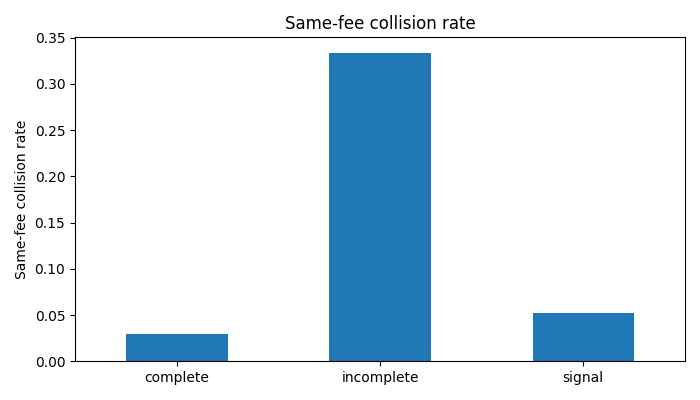

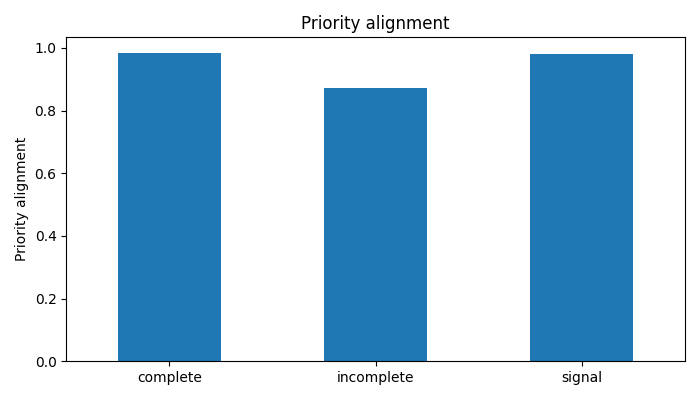

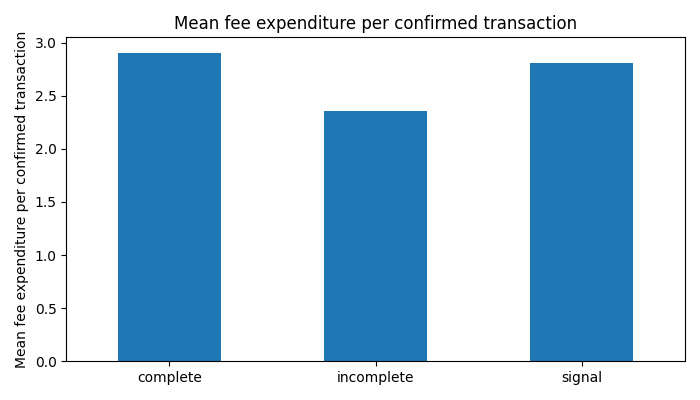

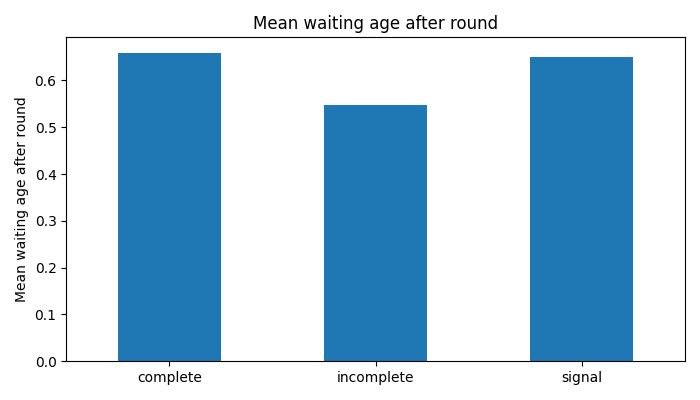

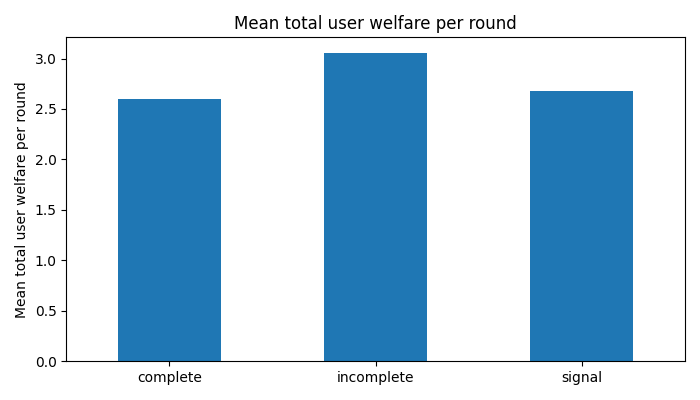

In [5]:
metrics_to_plot = [
    ("same_fee_rate", "Same-fee collision rate"),
    ("priority_alignment", "Priority alignment"),
    ("mean_fee_expenditure", "Mean fee expenditure per confirmed transaction"),
    ("mean_wait_after", "Mean waiting age after round"),
    ("mean_welfare_per_round", "Mean total user welfare per round"),
]

for column, title in metrics_to_plot:
    ax = summary[column].plot(kind="bar", figsize=(7, 4))
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(title)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


## 7. Round-by-round dynamics

Because waiting carries across rounds, aggregate averages can hide state changes. We therefore also report each condition by round.

This checks whether differences become larger after waiting has accumulated.


In [6]:
round_summary = (
    simulation.groupby(["condition", "round"])
    .agg(
        same_fee_rate=("same_fee", "mean"),
        mean_fee_expenditure=("fee_expenditure", "mean"),
        mean_welfare=("total_welfare", "mean"),
        mean_wait_after=("mean_wait_after", "mean"),
        priority_alignment=("priority_aligned", "mean"),
    )
    .reset_index()
)

round_summary.round(4)


,condition,round,same_fee_rate,mean_fee_expenditure,mean_welfare,mean_wait_after,priority_alignment
0,complete,1,0.0297,2.8024,3.3247,0.5000,0.984471
1,complete,2,0.0285,2.9565,2.6916,0.7370,0.98499
2,complete,3,0.0293,2.9563,1.7781,0.7403,0.984636
3,incomplete,1,0.5046,1.8719,4.2279,0.5000,0.969933
4,incomplete,2,0.4536,2.3791,2.5860,0.6237,0.75082
5,incomplete,3,0.0425,2.8053,2.3570,0.5200,0.965881
6,signal,1,0.0590,2.6633,3.4568,0.5000,0.983579
7,signal,2,0.0390,2.8681,2.7567,0.7316,0.97707
8,signal,3,0.0580,2.9054,1.8205,0.7176,0.98173


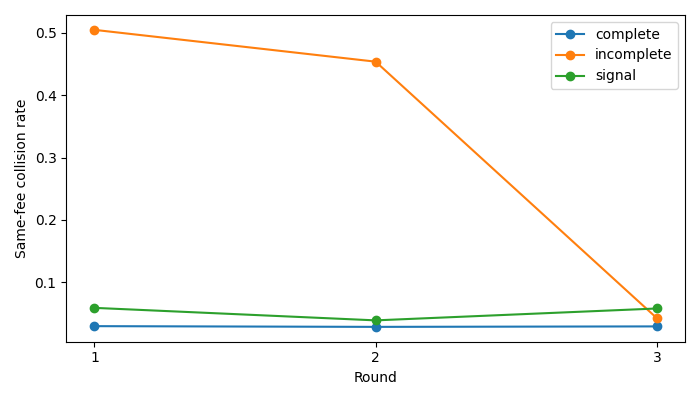

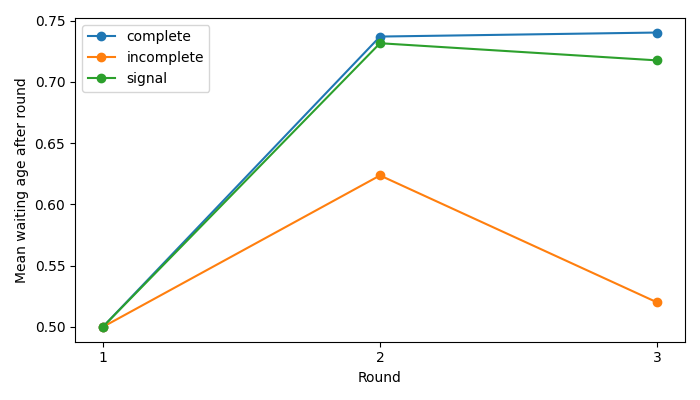

In [7]:
for metric, ylabel in [
    ("same_fee_rate", "Same-fee collision rate"),
    ("mean_wait_after", "Mean waiting age after round"),
]:
    plt.figure(figsize=(7, 4))
    for condition in ["complete", "incomplete", "signal"]:
        part = round_summary[round_summary["condition"] == condition]
        plt.plot(part["round"], part[metric], marker="o", label=condition)
    plt.xlabel("Round")
    plt.ylabel(ylabel)
    plt.xticks([1, 2, 3])
    plt.legend()
    plt.tight_layout()
    plt.show()


## 8. Signal-following sensitivity

The signal is nonbinding. Its effect should therefore depend on the probability that users follow it.

We vary

$$
\rho\in[0,1]
$$

and rerun the signal condition. This is a robustness check on the coordination mechanism rather than evidence about actual human compliance.


In [8]:
sensitivity_rows = []

for rho in np.linspace(0, 1, 11):
    df = run_condition(
        "signal",
        n_sessions=30_000,
        seed=BASE_SEED + int(rho * 10_000),
        signal_follow=float(rho),
    )
    sensitivity_rows.append({
        "signal_follow": rho,
        "same_fee_rate": df["same_fee"].mean(),
        "priority_alignment": df["priority_aligned"].mean(),
            "mean_fee_expenditure": df["fee_expenditure"].mean(),
        "mean_welfare": df["total_welfare"].mean(),
        "mean_wait_after": df["mean_wait_after"].mean(),
    })

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.round(4)


,signal_follow,same_fee_rate,priority_alignment,mean_fee_expenditure,mean_welfare,mean_wait_after
0,0.0,0.3332,0.8715,2.3507,3.0569,0.5476
1,0.1,0.2844,0.8893,2.4058,3.0108,0.5612
2,0.2,0.2396,0.9050,2.4574,2.9627,0.5747
3,0.3,0.1999,0.9227,2.5074,2.9174,0.5892
4,0.4,0.1634,0.9374,2.5621,2.8846,0.6050
5,0.5,0.1332,0.9486,2.6121,2.8398,0.6139
6,0.6,0.1060,0.9597,2.6707,2.7941,0.6270
7,0.7,0.0803,0.9691,2.7275,2.7544,0.6378
8,0.8,0.0598,0.9770,2.7849,2.6999,0.6472
9,0.9,0.0426,0.9818,2.8444,2.6570,0.6542


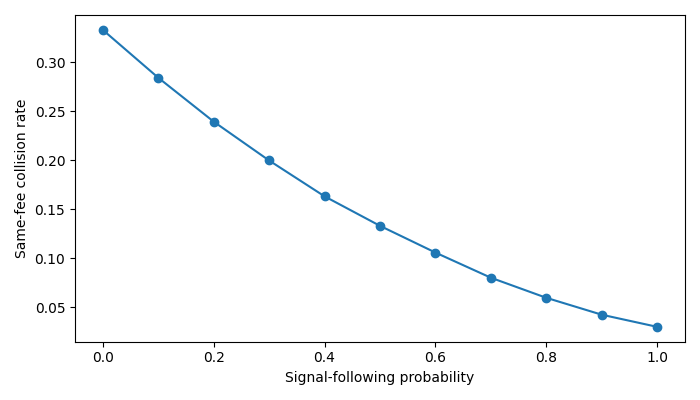

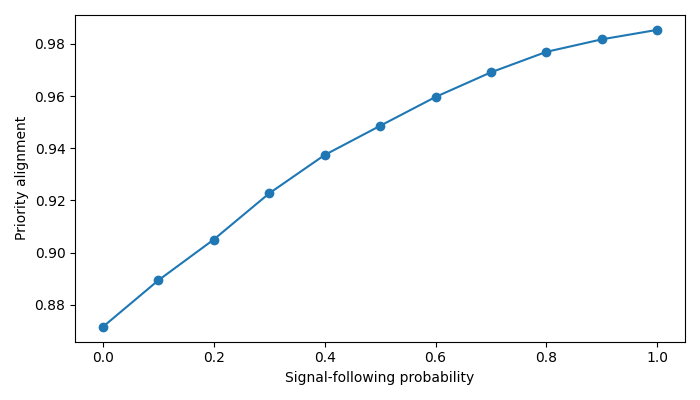

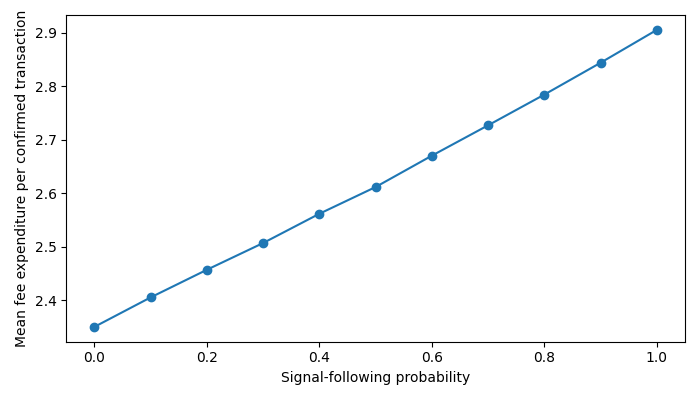

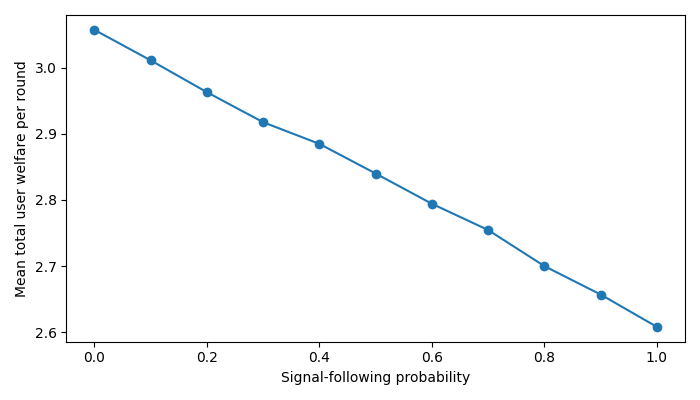

In [9]:
for metric, ylabel in [
    ("same_fee_rate", "Same-fee collision rate"),
    ("priority_alignment", "Priority alignment"),
    ("mean_fee_expenditure", "Mean fee expenditure per confirmed transaction"),
    ("mean_welfare", "Mean total user welfare per round"),
]:
    plt.figure(figsize=(7, 4))
    plt.plot(sensitivity["signal_follow"], sensitivity[metric], marker="o")
    plt.xlabel("Signal-following probability")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


## 9. Interpretation and next step

The notebook connects a strategic prediction to an allocation comparison.

The **stage Bayesian Nash benchmark** predicts a same-fee High outcome when each user expects the other to choose High. This captures the strategic tension: individually rational fee escalation can fail to differentiate priority.

The simulations then compare three information and coordination conditions using the same three-round state transition. The main outcomes are same-fee collision, priority alignment, urgent-user confirmation, waiting, and total welfare. These measures are intentionally separate. A mechanism can improve priority allocation while increasing fee expenditure, so better coordination does not automatically imply higher measured welfare.

The signal-sensitivity analysis varies the probability of following the nonbinding recommendation and shows how allocation outcomes depend on compliance. The Hugging Face game provides the corresponding behavioral interface. A next step is to compare participant fee choices, beliefs, and signal compliance with both the stage-game prediction and the computational allocation results.


## References used for the model framing

- Harsanyi, J. C. (1968). *Games with Incomplete Information Played by “Bayesian” Players, II: Bayesian Equilibrium Points*. Management Science, 14(5), 320–334. https://doi.org/10.1287/mnsc.14.5.320
- Gilad, Y., Hemo, R., Micali, S., Vlachos, G., & Zeldovich, N. (2017). *Algorand: Scaling Byzantine Agreements for Cryptocurrencies*. SOSP 2017, 51–68. https://doi.org/10.1145/3132747.3132757
- Roughgarden, T. (2024). *Transaction Fee Mechanism Design*. Journal of the ACM, 71(4), Article 30. https://doi.org/10.1145/3674143


In [10]:
summary.to_csv("condition_summary.csv")
round_summary.to_csv("round_summary.csv", index=False)
sensitivity.to_csv("signal_sensitivity.csv", index=False)

print("Saved:")
print("  condition_summary.csv")
print("  round_summary.csv")
print("  signal_sensitivity.csv")


Saved:
  condition_summary.csv
  round_summary.csv
  signal_sensitivity.csv
